# Modeling Spatial Variability: CNN vs Rook/Queen & Graph Laplacian

**Objective.** Simulate a field yield surface; learn local patterns with a CNN; build Rook/Queen spatial contiguity and a Laplacian smoother; then compare **prediction accuracy** and **variance components** side-by-side. Also compare **learned CNN kernels** to **Rook/Queen** stencils.


In [1]:
# ============= Configuration =============
GRID_NROWS = 40
GRID_NCOLS = 40
RANDOM_SEED = 42
TRAIN_FRAC = 0.7
LAMBDA_LAPL = 1.0   # smoothing strength for Laplacian model

import sys, subprocess, importlib
def ensure(pkg, pip_name=None):
    pip_name = pip_name or pkg
    try:
        importlib.import_module(pkg)
    except Exception:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from numpy.linalg import norm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
rng = np.random.default_rng(RANDOM_SEED)


## 1) Simulate Field Geometry & Synthetic Yield
We simulate a rectangular grid and blend latent components (trend, stripes, blobs, noise). We save the components to analyze variance and correlations later.

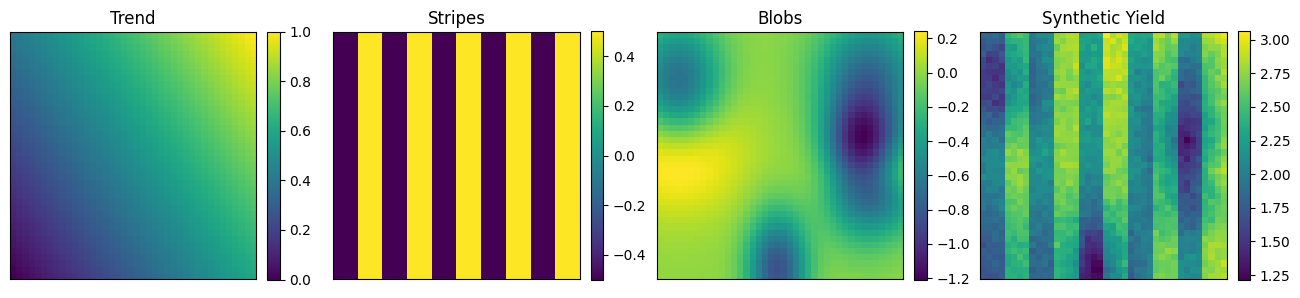

In [2]:
nr, nc = GRID_NROWS, GRID_NCOLS
ygrid, xgrid = np.mgrid[0:nr, 0:nc]

# Components
trend = 0.6*(xgrid/(nc-1)) + 0.4*(ygrid/(nr-1))
stripe_w = 4
stripes = ((xgrid // stripe_w) % 2).astype(float)
stripes = (stripes - stripes.mean())

def gaussian_blob(cx, cy, sx, sy, amp):
    return amp * np.exp(-(((xgrid-cx)**2)/(2*sx**2) + ((ygrid-cy)**2)/(2*sy**2)))

num_blobs = 8
blobs = np.zeros_like(trend)
for _ in range(num_blobs):
    cx, cy = rng.integers(0, nc), rng.integers(0, nr)
    sx, sy = float(rng.uniform(2.5, 8.0)), float(rng.uniform(2.5, 8.0))
    amp = float(rng.uniform(0.4, 1.0)) * float(rng.choice([-1, 1]))
    blobs += gaussian_blob(cx, cy, sx, sy, amp)

noise = rng.normal(0, 0.05, size=(nr, nc))

yield_surface = 2.0 + 0.9*trend + 0.6*stripes + 0.8*blobs + noise

fig, axs = plt.subplots(1, 4, figsize=(16,4))
for ax, im, title in zip(
    axs,
    [trend, stripes, blobs, yield_surface],
    ["Trend", "Stripes", "Blobs", "Synthetic Yield"],
):
    m = ax.imshow(im, origin='lower')
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(m, ax=ax, fraction=0.046, pad=0.04)
plt.show()


## 2) Rook & Queen Adjacency and Laplacian
Unnormalized Laplacian $L=D-A$ on the rectangular grid.

In [ ]:
def grid_index(r, c, nc):
    return r*nc + c

def build_adjacency(nr, nc, mode='rook'):
    rows, cols, data = [], [], []
    for r in range(nr):
        for c in range(nc):
            i = grid_index(r,c,nc)
            nbrs = []
            for dr, dc in [(1,0),(-1,0),(0,1),(0,-1)]:
                rr, cc = r+dr, c+dc
                if 0 <= rr < nr and 0 <= cc < nc:
                    nbrs.append(grid_index(rr,cc,nc))
            if mode == 'queen':
                for dr in (-1,0,1):
                    for dc in (-1,0,1):
                        if dr==0 and dc==0: continue
                        rr, cc = r+dr, c+dc
                        if 0 <= rr < nr and 0 <= cc < nc:
                            j = grid_index(rr,cc,nc)
                            if j not in nbrs:
                                nbrs.append(j)
            for j in nbrs:
                rows.append(i); cols.append(j); data.append(1.0)
    N = nr*nc
    import scipy.sparse as sp
    A = sp.coo_matrix((data, (rows, cols)), shape=(N,N)).tocsr()
    return A

A_rook  = build_adjacency(nr, nc, 'rook')
A_queen = build_adjacency(nr, nc, 'queen')
D_rook  = sp.diags(A_rook.sum(axis=1).A1)
D_queen = sp.diags(A_queen.sum(axis=1).A1)
L_rook  = D_rook - A_rook
L_queen = D_queen - A_queen
print(A_rook.shape, A_queen.shape)


## 3) Laplacian Smoother (Tikhonov)

In [ ]:
yvec = yield_surface.reshape(-1)
N = yvec.size
mask = rng.random(N) < TRAIN_FRAC
W = sp.diags(mask.astype(float))

def lap_smooth(L, y, W, lam):
    M = W + lam*L
    rhs = W @ y
    yhat = spla.spsolve(M.tocsc(), rhs)
    return yhat

yhat_rook  = lap_smooth(L_rook,  yvec, W, LAMBDA_LAPL)
yhat_queen = lap_smooth(L_queen, yvec, W, LAMBDA_LAPL)

def metrics(y_true, y_pred, test_mask):
    r = y_true[test_mask] - y_pred[test_mask]
    mse = float(np.mean(r**2))
    mae = float(np.mean(np.abs(r)))
    ss_res = float(np.sum(r**2))
    ss_tot = float(np.sum((y_true[test_mask]-np.mean(y_true[test_mask]))**2))
    r2 = 1 - ss_res/ss_tot if ss_tot>0 else 0.0
    return mse, mae, r2

test_mask = ~mask
m_rook  = metrics(yvec, yhat_rook,  test_mask)
m_queen = metrics(yvec, yhat_queen, test_mask)
print("Laplacian smoother metrics (MSE, MAE, R2):")
print(" Rook :", np.round(m_rook,3))
print(" Queen:", np.round(m_queen,3))


## 4) Fixed 3×3 Kernel Models (Rook/Queen stencils)

In [ ]:
from scipy.signal import convolve2d
rook3 = np.array([[0,1,0],[1,0,1],[0,1,0]], float)
rook3 = rook3/rook3.sum()
queen3 = np.ones((3,3), float); queen3[1,1]=0; queen3 = queen3/queen3.sum()

def conv_pred(yield_img, K):
    resp = convolve2d(yield_img, K[::-1, ::-1], mode='same', boundary='symm')
    return resp

resp_rook3  = conv_pred(yield_surface, rook3).reshape(-1)
resp_queen3 = conv_pred(yield_surface, queen3).reshape(-1)

def fit_affine(resp, y, train_mask):
    X = np.vstack([resp[train_mask], np.ones(train_mask.sum())]).T
    w, *_ = np.linalg.lstsq(X, y[train_mask], rcond=None)
    a,b = w
    return a,b

a_r,b_r = fit_affine(resp_rook3, yvec, mask)
a_q,b_q = fit_affine(resp_queen3, yvec, mask)
yhat_r3 = a_r*resp_rook3 + b_r
yhat_q3 = a_q*resp_queen3 + b_q

def metrics_vec(y_true, y_pred, test_mask):
    r = y_true[test_mask] - y_pred[test_mask]
    mse = float(np.mean(r**2))
    mae = float(np.mean(np.abs(r)))
    ss_res = float(np.sum(r**2))
    ss_tot = float(np.sum((y_true[test_mask]-np.mean(y_true[test_mask]))**2))
    r2 = 1 - ss_res/ss_tot if ss_tot>0 else 0.0
    return mse, mae, r2

m_r3 = metrics_vec(yvec, yhat_r3, test_mask)
m_q3 = metrics_vec(yvec, yhat_q3, test_mask)
print("3x3-kernel models (MSE, MAE, R2):")
print(" Rook-3x3 :", np.round(m_r3,3))
print(" Queen-3x3:", np.round(m_q3,3))


## 5) CNN Regressor & Learned 3×3 Kernels

In [ ]:
def extract_patches(img, patch=9):
    pad = patch//2
    padded = np.pad(img, pad, mode='reflect')
    H, W = img.shape
    Xs, ys = [], []
    for i in range(H):
        for j in range(W):
            pi, pj = i+pad, j+pad
            patch_ij = padded[pi-pad:pi+pad+1, pj-pad:pj+pad+1]
            Xs.append(patch_ij)
            ys.append(img[i,j])
    X = np.stack(Xs, 0).astype('float32')[:,None,:,:]
    y = np.array(ys, dtype='float32')[:,None]
    return X, y

X_img, y_img = extract_patches(yield_surface, patch=9)
idx = np.arange(X_img.shape[0]); np.random.shuffle(idx)
cut = int(TRAIN_FRAC*len(idx))
idx_train, idx_test = idx[:cut], idx[cut:]

class TinyCNN(nn.Module):
    def __init__(self, K=8):
        super().__init__()
        self.conv = nn.Conv2d(1, K, kernel_size=3, padding=0, bias=False)
        self.head = nn.Sequential(nn.ReLU(inplace=True), nn.Conv2d(K,1,kernel_size=1,bias=True))
        self.pool = nn.AdaptiveAvgPool2d((1,1))
    def forward(self, x):
        h = self.conv(x); h = self.head(h); h = self.pool(h).squeeze(-1).squeeze(-1)
        return h

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TinyCNN(K=8).to(device)
X_t = torch.from_numpy(X_img).to(device)
y_t = torch.from_numpy(y_img).to(device)
ds_train = TensorDataset(X_t[idx_train], y_t[idx_train])
ds_test  = TensorDataset(X_t[idx_test],  y_t[idx_test])
dl_train = DataLoader(ds_train, batch_size=512, shuffle=True)
dl_test  = DataLoader(ds_test,  batch_size=1024)

opt = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
for epoch in range(30):
    model.train(); tot=0
    for xb,yb in dl_train:
        opt.zero_grad(); pred = model(xb); loss = loss_fn(pred, yb.squeeze(1))
        loss.backward(); opt.step(); tot += loss.item()*xb.size(0)
    if (epoch+1)%10==0:
        print(f"Epoch {epoch+1:02d} train MSE={tot/len(ds_train):.6f}")

model.eval();
with torch.no_grad():
    yh = []
    for xb,yb in dl_test:
        yh.append(model(xb).cpu().numpy())
    yh = np.concatenate(yh,0).reshape(-1)

yt = y_img[idx_test].reshape(-1)
cnn_mse = float(np.mean((yt - yh)**2))
cnn_mae = float(np.mean(np.abs(yt - yh)))
ss_res = float(np.sum((yt - yh)**2)); ss_tot = float(np.sum((yt - np.mean(yt))**2))
cnn_r2  = 1 - ss_res/ss_tot
print("CNN metrics (MSE, MAE, R2):", np.round([cnn_mse, cnn_mae, cnn_r2],3))

with torch.no_grad(): learned = model.conv.weight.cpu().numpy()[:,0,:,:]
fig, axs = plt.subplots(1, learned.shape[0], figsize=(2.3*learned.shape[0], 2.4))
for i in range(learned.shape[0]):
    L = learned[i]; v = np.abs(L).max()
    im = axs[i].imshow(L, cmap='bwr', vmin=-v, vmax=v)
    axs[i].set_title(f"L{i}"); axs[i].set_xticks([]); axs[i].set_yticks([])
plt.show()


## 6) Learned vs Rook/Queen: Similarity & Response Maps

In [ ]:
rook3 = np.array([[0,1,0],[1,0,1],[0,1,0]], float); rook3/=rook3.sum()
queen3 = np.ones((3,3), float); queen3[1,1]=0; queen3/=queen3.sum()
def cosine_sim(A,B):
    a,b = A.reshape(-1), B.reshape(-1)
    na,nb = norm(a)+1e-12, norm(b)+1e-12
    return float((a@b)/(na*nb))
sims_rook = [cosine_sim(learned[i], rook3) for i in range(learned.shape[0])]
sims_queen= [cosine_sim(learned[i], queen3) for i in range(learned.shape[0])]
br, bq = int(np.argmax(sims_rook)), int(np.argmax(sims_queen))
print("Cosine sim to Rook:", np.round(sims_rook,3))
print("Cosine sim to Queen:", np.round(sims_queen,3))

from scipy.signal import convolve2d
def conv2(img, K):
    return convolve2d(img, K[::-1, ::-1], mode='same', boundary='symm')
resp_rook_map = conv2(yield_surface, rook3)
resp_queen_map= conv2(yield_surface, queen3)
resp_Lr_map   = conv2(yield_surface, learned[br])
resp_Lq_map   = conv2(yield_surface, learned[bq])

fig, axs = plt.subplots(2,2, figsize=(10,8))
axs[0,0].imshow(rook3, cmap='bwr'); axs[0,0].set_title('Rook 3x3')
axs[0,1].imshow(learned[br], cmap='bwr'); axs[0,1].set_title(f'Learned L{br}')
axs[1,0].imshow(resp_rook_map, origin='lower'); axs[1,0].set_title('Rook response')
axs[1,1].imshow(resp_Lr_map, origin='lower'); axs[1,1].set_title('L{br} response')
for ax in axs.ravel(): ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

fig, axs = plt.subplots(2,2, figsize=(10,8))
axs[0,0].imshow(queen3, cmap='bwr'); axs[0,0].set_title('Queen 3x3')
axs[0,1].imshow(learned[bq], cmap='bwr'); axs[0,1].set_title(f'Learned L{bq}')
axs[1,0].imshow(resp_queen_map, origin='lower'); axs[1,0].set_title('Queen response')
axs[1,1].imshow(resp_Lq_map, origin='lower'); axs[1,1].set_title('L{bq} response')
for ax in axs.ravel(): ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 7) Accuracy, Variance Components, and Moran's I

In [ ]:
def morans_I(resid, A):
    z = resid - resid.mean(); N=len(z)
    W = A.copy().astype(float)
    row_sums = np.array(W.sum(axis=1)).reshape(-1)
    row_sums[row_sums==0]=1
    W = sp.diags(1.0/row_sums) @ W
    zWz = float(z @ (W @ z)); zz = float(z @ z)
    return (N / W.count_nonzero()) * (zWz / (zz + 1e-12))

yvec = yield_surface.reshape(-1)
test_mask = ~mask

# CNN full-field proxy to align vectors for variance/MoranI
yhat_cnn_full = np.zeros_like(yvec)
# reconstruct CNN prediction at all locations by evaluating on all patches
with torch.no_grad():
    yhat_all = model(torch.from_numpy(X_img).to(device)).cpu().numpy().reshape(-1)
yhat_cnn_full = yhat_all

def metrics_all(y, yhat, test_mask):
    r = y[test_mask]-yhat[test_mask]
    mse = float(np.mean(r**2))
    mae = float(np.mean(np.abs(r)))
    ss_res = float(np.sum(r**2))
    ss_tot = float(np.sum((y[test_mask]-np.mean(y[test_mask]))**2))
    r2 = 1 - ss_res/ss_tot if ss_tot>0 else 0.0
    return mse, mae, r2

def variance_report(y, yhat, name):
    var_total = float(np.var(y[test_mask], ddof=1))
    mse, mae, r2 = metrics_all(y, yhat, test_mask)
    var_resid = float(np.var((y - yhat)[test_mask], ddof=1))
    var_expl  = max(var_total - var_resid, 0.0)
    I = morans_I((y - yhat), A_rook)
    return {'model':name,'MSE':mse,'MAE':mae,'R2':r2,'Var_total':var_total,'Var_explained':var_expl,'Var_residual':var_resid,'MoranI_residual':I}

rep_lap_rook  = variance_report(yvec, yhat_rook,  'Laplacian-Rook')
rep_lap_queen = variance_report(yvec, yhat_queen, 'Laplacian-Queen')
rep_r3        = variance_report(yvec, yhat_r3,    'Rook-3x3 (affine)')
rep_q3        = variance_report(yvec, yhat_q3,    'Queen-3x3 (affine)')
rep_cnn       = variance_report(yvec, yhat_cnn_full, 'CNN (local)')

import pandas as pd
df = pd.DataFrame([rep_lap_rook,rep_lap_queen,rep_r3,rep_q3,rep_cnn])
df[['model','MSE','MAE','R2','Var_total','Var_explained','Var_residual','MoranI_residual']]


## 8) Correlations with Latent Components

In [ ]:
def corr(a,b):
    a=a.reshape(-1); b=b.reshape(-1)
    if a.std()==0 or b.std()==0: return 0.0
    return float(np.corrcoef(a,b)[0,1])

pred_maps = {
    'Laplacian-Rook' : yhat_rook.reshape(nr,nc),
    'Laplacian-Queen': yhat_queen.reshape(nr,nc),
    'Rook-3x3 (affine)': yhat_r3.reshape(nr,nc),
    'Queen-3x3 (affine)': yhat_q3.reshape(nr,nc),
    'CNN (local)' : yhat_cnn_full.reshape(nr,nc),
}

rows=[]
for name,pm in pred_maps.items():
    rows.append({'model':name,'corr_trend':corr(pm,trend),'corr_stripes':corr(pm,stripes),'corr_blobs':corr(pm,blobs)})
import pandas as pd
pd.DataFrame(rows)


## 9) Notes & Next Steps
- Swap to **Queen Laplacian** in the smoother or test distance-weighted graphs.
- Use **block spatial CV** for more realistic evaluation.
- Port this to your real shapefile grid and compute adjacency from true plot neighbors.
